In [2]:
library(Seurat)
library(SeuratData)
library(patchwork)
library(ggplot2)
library(purrr)
library(dplyr)
library(stringr)
library(tidyverse)
library(ggpubr)
library(RColorBrewer)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




ERROR: Error in library(SeuratData): there is no package called ‘SeuratData’


In [ ]:
library(rcompanion)

In [53]:
lownames <- readRDS('lownames.rds')
highnames <- readRDS('highnames.rds')

In [3]:
GCA_data <- readRDS('GCA_obj_subset_excludecells3.Rdata')

In [4]:
ploidy <- read.table('/disk1/pengweixing/esophageal/26.copyKat/copykat2_copykat_prediction.txt',header=T)

In [38]:
cnv_score <- readRDS('combined_score_forbox2.Rds')

In [62]:
cnv_score  %>% mutate(group = ifelse(score< 0.2291667,'Low_CNV','High_CNV' )) -> cnv_score

In [5]:
rownames(ploidy) <- ploidy$cell.names

In [23]:
#GCA_data@meta.data  %>%  filter(celltype=='Epi_tumor'|celltype=='Epi_normal')%>% 
#        rownames()  %>%  GCA_data[,.] -> GCA_obj_subset_Epi

In [24]:
GCA_data@meta.data  %>%  filter(celltype=='Epi_tumor')%>% 
        rownames()  %>%  GCA_data[,.] -> GCA_obj_subset_Epi

In [25]:
GCA_obj_subset_Epi  %>% colnames()  %>% ploidy[.,]   %>% .[,2] -> GCA_obj_subset_Epi$ploidy

In [ ]:
GCA_obj_subset_Epi[["RNA"]] <- split(GCA_obj_subset_Epi[["RNA"]], 
                                           f = GCA_obj_subset_Epi$sample)

In [ ]:
GCA_obj_subset_Epi <- NormalizeData(GCA_obj_subset_Epi, normalization.method = "LogNormalize", 
                                           scale.factor = 10000)

In [ ]:
all.genes <- rownames(GCA_obj_subset_Epi)
GCA_obj_subset_Epi <- FindVariableFeatures(GCA_obj_subset_Epi, selection.method = "vst", 
                                                  nfeatures = 2000)
GCA_obj_subset_Epi <- ScaleData(GCA_obj_subset_Epi, features = all.genes)
GCA_obj_subset_Epi <- RunPCA(GCA_obj_subset_Epi, features = 
                                    VariableFeatures(object = GCA_obj_subset_Epi))

In [29]:
GCA_obj_subset_Epi <- IntegrateLayers(object = GCA_obj_subset_Epi, method = CCAIntegration, orig.reduction = "pca",
                        new.reduction = "integrated.cca",verbose = FALSE)

In [30]:
# re-join layers after integration
GCA_obj_subset_Epi[["RNA"]] <- JoinLayers(GCA_obj_subset_Epi[["RNA"]])

In [31]:
GCA_obj_subset_Epi <- FindNeighbors(GCA_obj_subset_Epi, dims = 1:30,reduction = "integrated.cca")

Computing nearest neighbor graph

Computing SNN



In [102]:
GCA_obj_subset_Epi <- FindClusters(GCA_obj_subset_Epi, resolution = 0.8)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 5131
Number of edges: 223201

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8346
Number of communities: 13
Elapsed time: 0 seconds


In [ ]:
GCA_obj_subset_Epi <- RunUMAP(GCA_obj_subset_Epi, dims = 1:30,reduction = "integrated.cca",)

In [109]:
p_epi <- DimPlot(GCA_obj_subset_Epi, reduction = "umap", label = FALSE,group.by ="RNA_snn_res.0.1" )

In [4]:
plot_dfaabb <- cbind(
  as.data.frame(Embeddings(GCA_obj_subset_Epi, reduction = "umap")),
  subcelltype = GCA_obj_subset_Epi@meta.data$RNA_snn_res.0.1,
  sample = GCA_obj_subset_Epi@meta.data$sample
)

head(plot_dfaabb)

,umap_1,umap_2,subcelltype,sample
,<dbl>,<dbl>,<fct>,<chr>
AAACGAAGTTACTCAG-1-SC005,-0.8000065,-4.5808606,1,SC005
AAAGAACGTAAGGAGA-1-SC005,5.8260623,3.9729679,5,SC005
AAAGAACGTGGCGCTT-1-SC005,-3.9945969,1.8674555,0,SC005
AAAGGGCAGTAGTCTC-1-SC005,-3.8488854,0.1794161,0,SC005
AAAGGTAGTCTTCAAG-1-SC005,0.2592881,0.2155745,1,SC005
AAAGGTAGTTGCTGAT-1-SC005,5.5123325,3.5572059,5,SC005


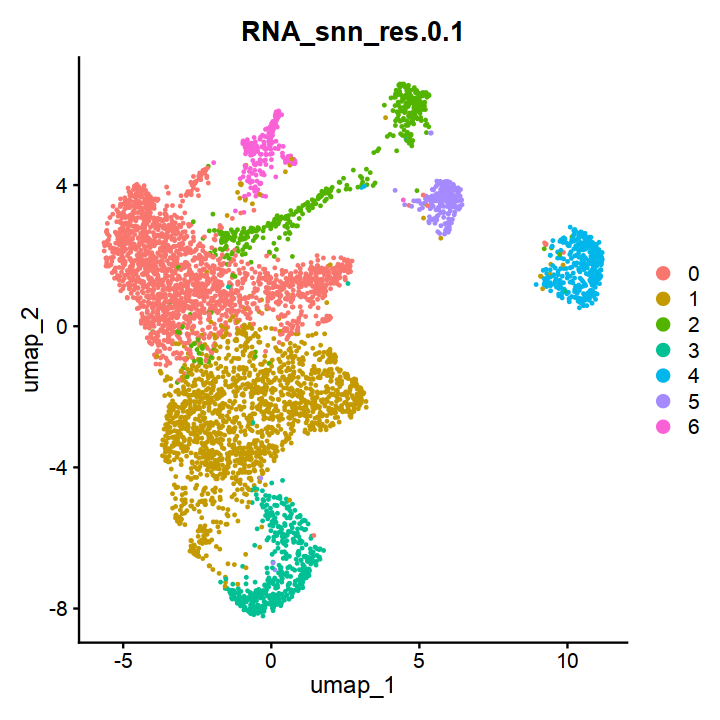

In [110]:
p_epi

In [111]:
ggsave(filename = "Umap_Epithelial_Cluster.pdf",plot = p_epi,width = 6,height = 6)

In [34]:
saveRDS(GCA_obj_subset_Epi,file = "GCA_epi.Rds")

In [59]:
cnv_score  %>% head()

,score,group
,<dbl>,<chr>
AAACCCACACAACGAG-1-SC032,0.1782315,High
AAAGAACTCTCCGAAA-1-SC032,0.3350451,High
AAAGTCCGTCATCGGC-1-SC032,0.3128758,High
AAAGTGATCAGTGTCA-1-SC032,0.2749248,High
AAATGGACAAGTGTCT-1-SC032,0.2741733,High
AAATGGAGTGGTCAAG-1-SC032,0.1161072,High


In [63]:
GCA_obj_subset_Epi@meta.data   %>% rownames()  %>% cnv_score[.,]  %>% pull(group)  -> GCA_obj_subset_Epi$cnv_group

In [6]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters
options(repr.plot.height=6,repr.plot.width=6)
p_high_cnv <- DimPlot(GCA_obj_subset_Epi, reduction = "umap", label = FALSE,group.by ="cnv_group" ,
        cols = c('#7fc97f','#984ea3'))

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


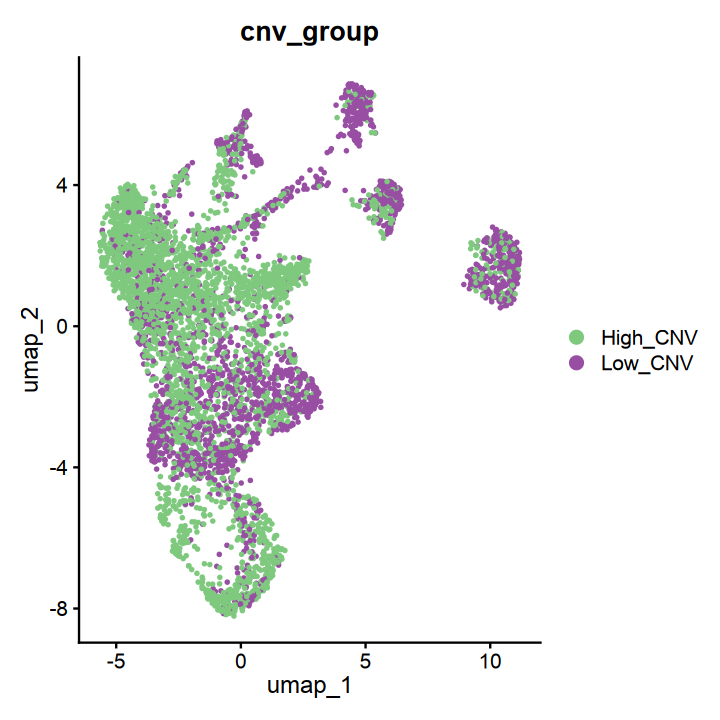

In [7]:
p_high_cnv

In [258]:
GCA_obj_subset_Epi@meta.data  %>% count(group,RNA_snn_res.0.1)  %>% group_by(RNA_snn_res.0.1)  %>% 
    reframe(group = group,n = n,pct = n/(sum(n))) -> cluster_group_pct

In [259]:
GCA_obj_subset_Epi@meta.data  %>% count(group) 

group,n
<chr>,<int>
High,3375
Low,1756


In [260]:
temp <- data.frame(RNA_snn_res.0.1 = c('all','all'),group = c('Low','High'),n = c(1756,3375),pct = c(1756/(1756+3375),3375/(1756+3375)))

In [261]:
rbind(temp,cluster_group_pct) -> cluster_group_pct

In [262]:
cluster_group_pct  %>% head(n= 3)

,RNA_snn_res.0.1,group,n,pct
,<chr>,<chr>,<dbl>,<dbl>
1,all,Low,1756,0.3422335
2,all,High,3375,0.6577665
3,0,High,1212,0.6405920


In [21]:
options(repr.plot.height=6,repr.plot.width=6)
pp1 <- ggplot(data = cluster_group_pct,aes(x=RNA_snn_res.0.1,y=pct,fill = group)) + geom_bar(stat = 'identity')+
    theme_bw() +xlab('') + theme(axis.text = element_text(color='black',size=15),
                                 axis.title = element_text(size=20),
                                 axis.text.x = element_text(angle=45,hjust=1)) + 
    geom_text(aes(label = scales::percent(pct)),position = position_stack(vjust = 0.5))+
    scale_fill_manual(values = c('#EC2626','#2F5688')) 

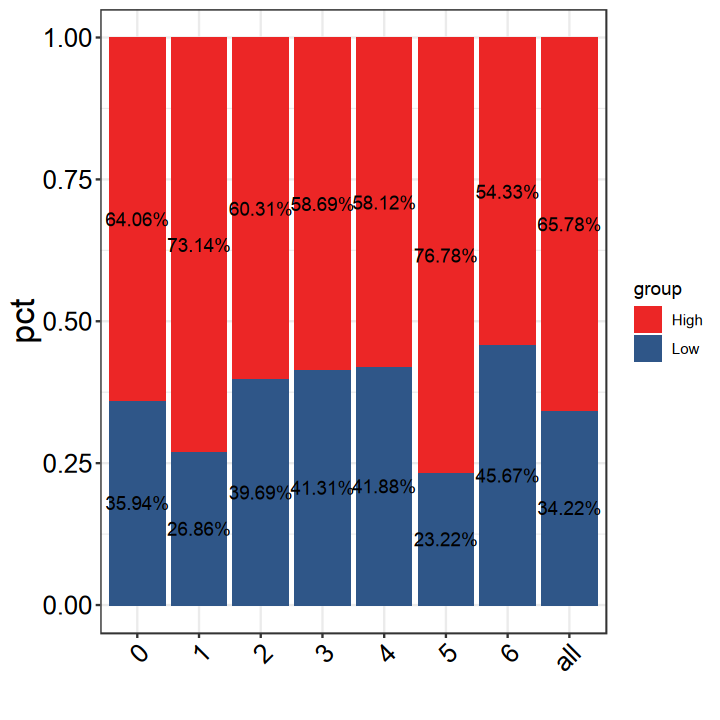

In [22]:
pp1

In [271]:
cluster_group_pct  %>% select(RNA_snn_res.0.1,group,n) %>% 
    pivot_wider(names_from = group,values_from = n) -> cluster_group_pct_wider

cluster_group_pct_wider_pvalue = as.data.frame(matrix(NA,nrow =8,ncol = 3 ))
colnames(cluster_group_pct_wider_pvalue) <- c('cluster','pvalue','cramerV')
for(i in 1:nrow(cluster_group_pct_wider)){
    temp = cluster_group_pct_wider[c(1,i),]  %>% select(High,Low)
    a =chisq.test(temp)[['p.value']]
    cluster_group_pct_wider_pvalue[i,1] = i - 1 
    cluster_group_pct_wider_pvalue[i,2] = a
    corr = cramerV(as.matrix(temp))
    cluster_group_pct_wider_pvalue[i,3] = corr
}

In [272]:
cluster_group_pct_wider

RNA_snn_res.0.1,Low,High
<chr>,<dbl>,<dbl>
all,1756,3375
0,680,1212
1,423,1152
2,179,272
3,183,260
4,147,204
5,49,162
6,95,113


In [273]:
cluster_group_pct_wider_pvalue

cluster,pvalue,cramerV
<dbl>,<dbl>,<dbl>
0,1.000000e+00,0.00000
1,1.890851e-01,0.01601
2,5.663073e-08,0.06667
3,2.219342e-02,0.03130
4,3.154193e-03,0.04024
5,4.271994e-03,0.03937
6,1.209170e-03,0.04530
7,8.773601e-04,0.04655


In [203]:
ggsave(filename  = "Bar_Epi_cluster_ERBB2group.pdf",plot = pp1,width = 6,height = 6)

In [13]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters 
options(repr.plot.height=6,repr.plot.width=6)
p_aneuploid <-  DimPlot(GCA_obj_subset_Epi, reduction = "umap", label = FALSE,group.by ="ploidy",
        cols = c('#1b9e77','#d95f02','gray'))

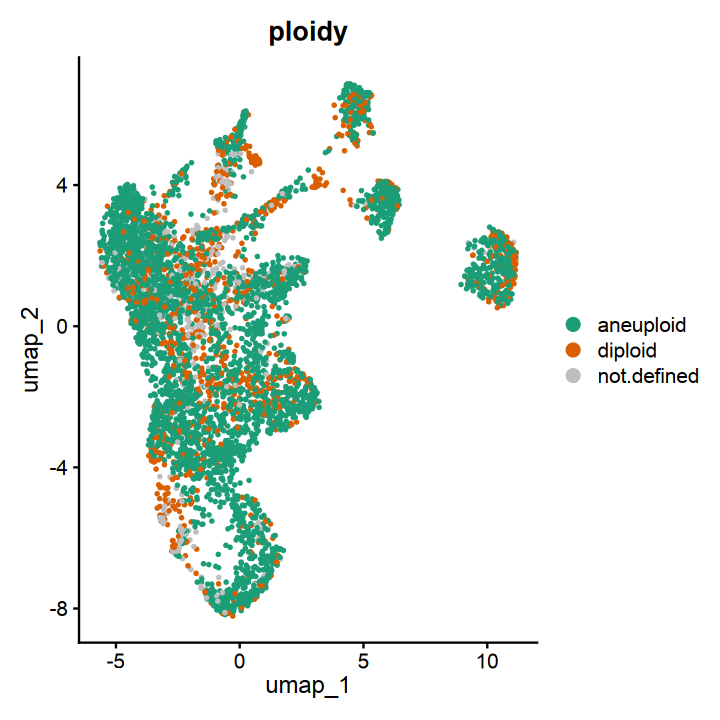

In [14]:
p_aneuploid

In [88]:
ggsave(filename = "Umap_CNV_Group.pdf",plot = p_high_cnv,width = 6,height = 6)

In [89]:
ggsave(filename = "Umap_Aeuploid_Group.pdf",plot = p_aneuploid,width = 6,height = 6)

In [66]:
GCA_obj_subset_Epi@meta.data  %>% mutate(group =ifelse(sample %in% highnames,'High','Low')) -> GCA_obj_subset_Epi$group

In [10]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters 
options(repr.plot.height=6,repr.plot.width=6)
p_group <- DimPlot(GCA_obj_subset_Epi, reduction = "umap", label = FALSE,group.by ="group",cols = c(
                                                                                         '#EC2626','#2F5688'
                                                                                        ) )

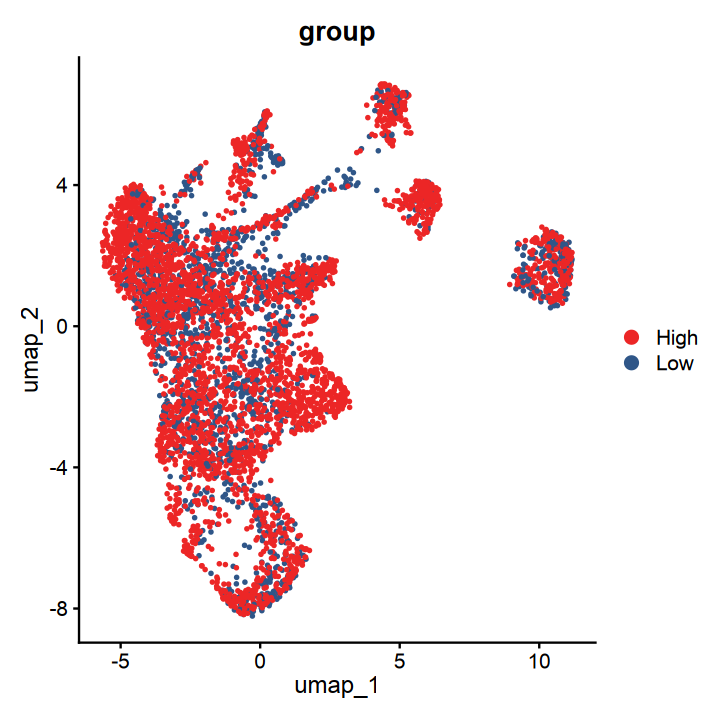

In [11]:
p_group

In [73]:
ggsave(filename = "Umap_Epithelial_Her2Group.pdf",plot = p_group,width = 6,height = 6)

In [246]:
GCA_obj_subset_Epi@meta.data  %>% count(cnv_group,RNA_snn_res.0.1)  %>% group_by(RNA_snn_res.0.1)  %>% 
    reframe(group = cnv_group,n = n,pct = n/(sum(n))) -> cluster_CNVgroup_pct

In [247]:
cluster_CNVgroup_pct  %>% head(n=3)

RNA_snn_res.0.1,group,n,pct
<fct>,<chr>,<int>,<dbl>
0,High_CNV,1591,0.8409091
0,Low_CNV,301,0.1590909
1,High_CNV,718,0.4558730


In [248]:
GCA_obj_subset_Epi@meta.data  %>% count(cnv_group)

cnv_group,n
<chr>,<int>
High_CNV,2990
Low_CNV,2141


In [249]:
temp <- data.frame(RNA_snn_res.0.1 = c('all','all'),group = c('High_CNV','Low_CNV'),
                   n = c(2990,2141),pct = c(2990/(2990+2141),2141/(2990+2141)))

In [250]:
temp

RNA_snn_res.0.1,group,n,pct
<chr>,<chr>,<dbl>,<dbl>
all,High_CNV,2990,0.5827324
all,Low_CNV,2141,0.4172676


In [251]:
rbind(temp,cluster_CNVgroup_pct) -> cluster_CNVgroup_pct

In [252]:
cluster_CNVgroup_pct  %>% head(n=3)

,RNA_snn_res.0.1,group,n,pct
,<chr>,<chr>,<dbl>,<dbl>
1,all,High_CNV,2990,0.5827324
2,all,Low_CNV,2141,0.4172676
3,0,High_CNV,1591,0.8409091


In [18]:
library(ggplot2)

In [19]:
options(repr.plot.height=6,repr.plot.width=6)
pp2 <- ggplot(data = cluster_CNVgroup_pct,aes(x=RNA_snn_res.0.1,y=pct,fill = group)) + geom_bar(stat = 'identity')+
    theme_bw() +xlab('') + theme(axis.text = element_text(color='black',size=15),
                                 axis.title = element_text(size=20),
                                 axis.text.x = element_text(angle=45,hjust=1)) + 
    geom_text(aes(label = scales::percent(pct)),position = position_stack(vjust = 0.5))+
    scale_fill_manual(values =  c('#7fc97f','#984ea3')) 

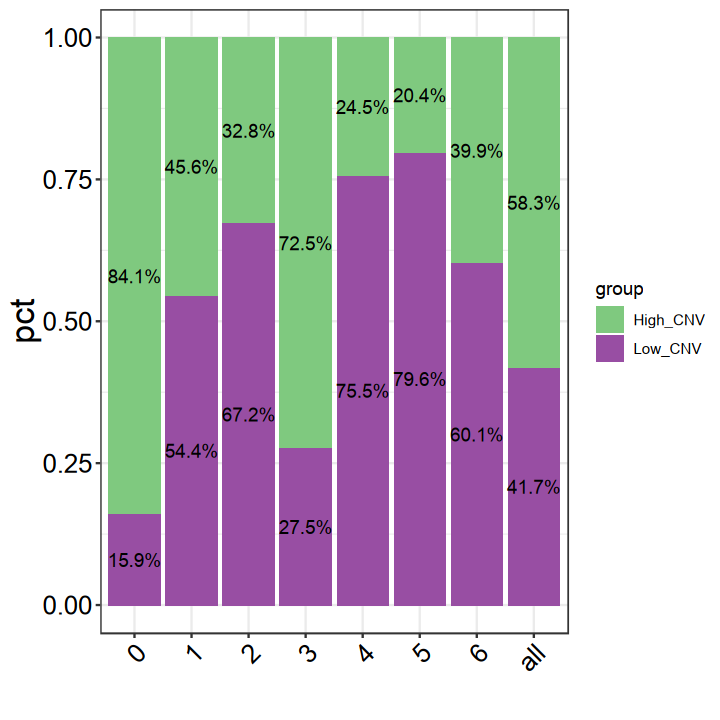

In [20]:
pp2

In [255]:
cluster_CNVgroup_pct  %>% select(RNA_snn_res.0.1,group,n) %>% 
    pivot_wider(names_from = group,values_from = n) -> cluster_CNVgroup_pct_wider

cluster_CNVgroup_pct_wider_pvalue = as.data.frame(matrix(NA,nrow =8,ncol = 3 ))
colnames(cluster_CNVgroup_pct_wider_pvalue) <- c('cluster','pvalue','cramerV')
for(i in 1:nrow(cluster_CNVgroup_pct_wider)){
    temp = cluster_CNVgroup_pct_wider[c(1,i),]  %>% select(High_CNV,Low_CNV)
    a =chisq.test(temp)[['p.value']]
    cluster_CNVgroup_pct_wider_pvalue[i,1] = i -1 
    cluster_CNVgroup_pct_wider_pvalue[i,2] = a
    corr = cramerV(as.matrix(temp))
    cluster_CNVgroup_pct_wider_pvalue[i,3] = corr
}

In [270]:
cluster_CNVgroup_pct_wider

RNA_snn_res.0.1,High_CNV,Low_CNV
<chr>,<dbl>,<dbl>
all,2990,2141
0,1591,301
1,718,857
2,148,303
3,321,122
4,86,265
5,43,168
6,83,125


In [256]:
cluster_CNVgroup_pct_wider_pvalue

cluster,pvalue,cramerV
<dbl>,<dbl>,<dbl>
0,1.000000e+00,0.00000
1,4.285419e-90,0.24050
2,1.060818e-18,0.10820
3,2.527596e-25,0.13980
4,7.314776e-09,0.07814
5,1.169115e-34,0.16660
6,2.802953e-27,0.14900
7,2.181943e-07,0.07191


In [202]:
ggsave(filename  = "Bar_Epi_cluster_CNVgroup.pdf",plot = pp2,width = 6,height = 6)

## ploidy

In [193]:
GCA_obj_subset_Epi@meta.data  %>% filter(ploidy %in% c('diploid','aneuploid')) %>% count(ploidy,RNA_snn_res.0.1)  %>% group_by(RNA_snn_res.0.1)  %>% 
    reframe(group = ploidy,n = n,pct = n/(sum(n))) -> cluster_ploidygroup_pct

In [194]:
GCA_obj_subset_Epi@meta.data  %>% count(ploidy)

ploidy,n
<chr>,<int>
aneuploid,3601
diploid,1083
not.defined,447


In [195]:
temp <- data.frame(RNA_snn_res.0.1 = c('all','all'),group = c('aneuploid','diploid'),
                   n = c(3601,1083),pct = c(3601/(3601+1083),1083/(3601+1083)))

In [196]:
rbind(temp,cluster_ploidygroup_pct) -> cluster_ploidygroup_pct

In [197]:
options(repr.plot.height=6,repr.plot.width=6)
pp4 <- ggplot(data = cluster_ploidygroup_pct,aes(x=RNA_snn_res.0.1,y=pct,fill = group)) + geom_bar(stat = 'identity')+
    theme_bw() +xlab('') + theme(axis.text = element_text(color='black',size=15),
                                 axis.title = element_text(size=20),
                                 axis.text.x = element_text(angle=45,hjust=1)) + 
    geom_text(aes(label = scales::percent(pct)),position = position_stack(vjust = 0.5))+
    scale_fill_manual(values = c('#1b9e77','#d95f02','gray')) 

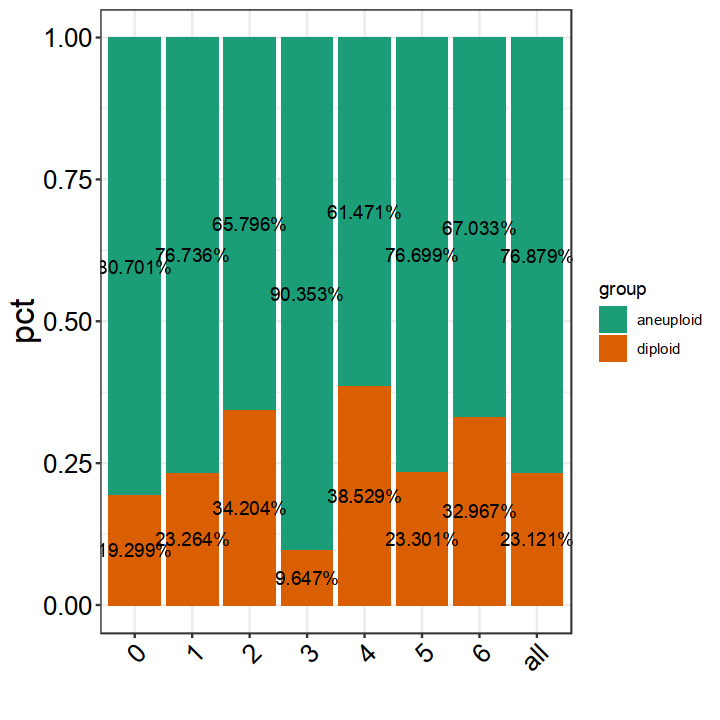

In [198]:
pp4

In [201]:
ggsave(filename  = "Bar_Epi_cluster_Ploidygroup.pdf",plot = pp4,width = 6,height = 6)

In [211]:
cluster_ploidygroup_pct  %>% select(RNA_snn_res.0.1,group,n) %>% 
    pivot_wider(names_from = group,values_from = n) -> cluster_ploidygroup_pct_wider

cluster_ploidygroup_pct_wider_pvalue = as.data.frame(matrix(NA,nrow =8,ncol = 3 ))
colnames(cluster_ploidygroup_pct_wider_pvalue) <- c('cluster','pvalue','cramerV')
for(i in 1:nrow(cluster_ploidygroup_pct_wider)){
    temp = cluster_ploidygroup_pct_wider[c(1,i),]  %>% select(aneuploid,diploid)
    a =chisq.test(temp)[['p.value']]
    cluster_ploidygroup_pct_wider_pvalue[i,1] = i -1 
    cluster_ploidygroup_pct_wider_pvalue[i,2] = a
    corr = cramerV(as.matrix(temp))
    cluster_ploidygroup_pct_wider_pvalue[i,3] = corr
}

In [232]:
cluster_ploidygroup_pct_wider_pvalue

cluster,pvalue,cramerV
<dbl>,<dbl>,<dbl>
0,1.000000e+00,0.0000000
1,1.554136e-03,0.0402700
2,9.378504e-01,0.0014430
3,4.698861e-07,0.0713500
4,2.024522e-10,0.0898300
5,2.255939e-10,0.0904100
6,1.000000e+00,0.0008561
7,2.836364e-03,0.0440700


In [326]:
Idents(GCA_obj_subset_Epi) <- 'RNA_snn_res.0.1'

In [ ]:
markers <- FindAllMarkers(GCA_obj_subset_Epi, only.pos = TRUE)

In [328]:
markers %>% group_by(cluster) %>% 
    dplyr::filter(avg_log2FC > 1&p_val_adj<0.01) ->  markers2

In [329]:
markers2  %>% filter(!str_detect(string = gene,pattern = 'LINC'))  -> markers2

In [330]:
markers2 %>% filter(!str_detect(string = gene,pattern = 'AS1'))  -> markers2

In [337]:
markers2  %>% mutate(pct = pct.1/pct.2)  %>% filter(pct.1>0.4)%>% group_by(cluster) %>% 
    slice_max(order_by = pct, n = 3) %>%  
    pull(gene) ->a

In [339]:
options(repr.plot.height=6,repr.plot.width=10)
p <- DotPlot(GCA_obj_subset_Epi, features = a) + RotatedAxis()

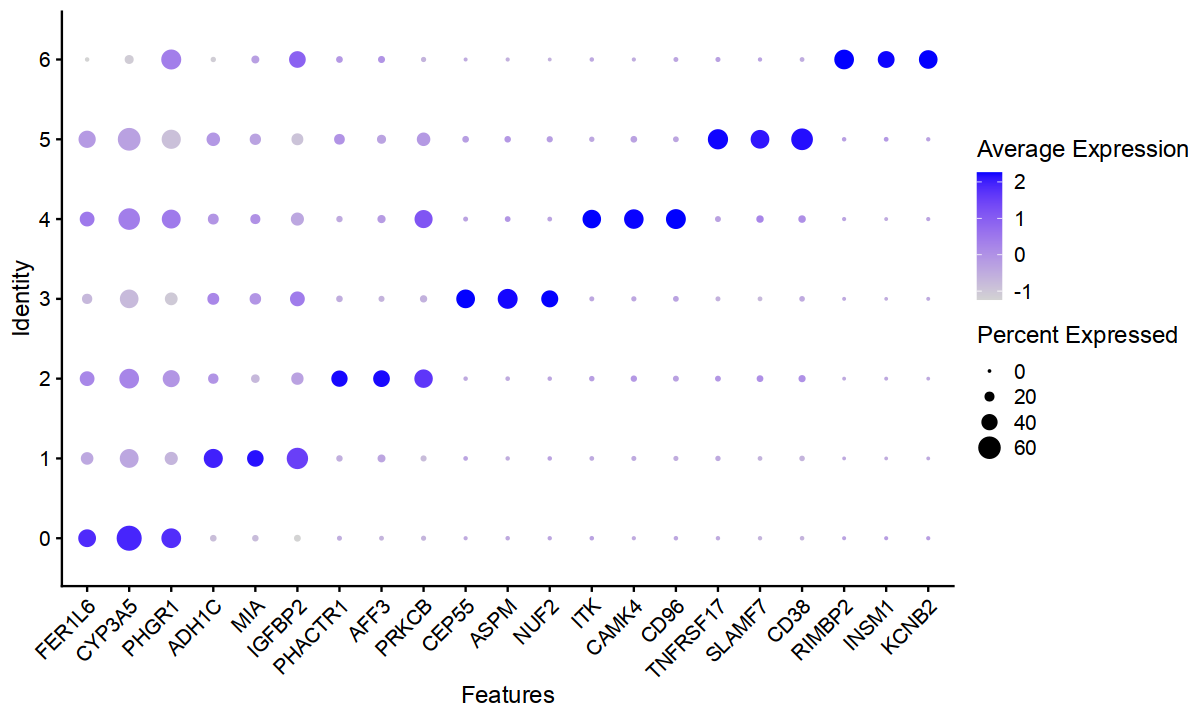

In [340]:
p

In [341]:
ggsave(filename  = "Bubble_markergenes.pdf",plot = p,width = 6,height = 6)

In [24]:
save.image('epithelial.Rds')

In [1]:
load('epithelial.Rds')

In [23]:
saveRDS(list(First = plot_dfaabb,
             Second_bar = pp1$data,
             Second = p_group$data,
             Third = p_high_cnv@data,
             Third_bar = pp2$data,
             Fourth = p_aneuploid$data,
            Fourth_bar = pp4$data),
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Figure6a.Rds")